In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Demo/CS4182_NLP

/content/drive/MyDrive/Demo/CS4182_NLP


Installing dependencies

In [ ]:
!pip install -q transformers datasets accelerate peft trl bitsandbytes evaluate
!pip install -q rouge_score bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.0 MB/s eta 0:00:00


Importing libraries

In [ ]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, TrainingArguments
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer
from datasets import load_dataset
import warnings
warnings.filterwarnings("ignore")

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

GPU available: True
GPU name: Tesla T4
VRAM: 15.6 GB


Loads the dataset

In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict

# Load your 3 CSV files
train_df = pd.read_csv("/content/drive/MyDrive/Demo/CS4182_NLP/train.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/Demo/CS4182_NLP/validation.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/Demo/CS4182_NLP/test.csv")


TEXT_COLUMN = "text"


train_text = " ".join(train_df[TEXT_COLUMN].dropna().astype(str).tolist())
val_text   = " ".join(val_df[TEXT_COLUMN].dropna().astype(str).tolist())
test_text  = " ".join(test_df[TEXT_COLUMN].dropna().astype(str).tolist())

# Build dataset
dataset = DatasetDict({
    "train":      Dataset.from_dict({"text": [train_text]}),
    "validation": Dataset.from_dict({"text": [val_text]}),
    "test":       Dataset.from_dict({"text": [test_text]}),
})

print(dataset)
print("\n--- Sample text (first 500 chars) ---")
print(dataset["train"]["text"][0][:500])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1
    })
    test: Dataset({
        features: ['text'],
        num_rows: 1
    })
})

--- Sample text (first 500 chars) ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


Preprocess the dataset

In [ ]:
def chunk_text(text, chunk_size=300):
    words = text.split()
    chunks = []
    current = []
    count = 0
    for word in words:
        current.append(word)
        count += len(word) + 1
        if count >= chunk_size:
            chunks.append({"text": " ".join(current)})
            current = []
            count = 0
    if current:
        chunks.append({"text": " ".join(current)})
    return chunks

train_chunks = chunk_text(dataset["train"]["text"][0])
val_chunks   = chunk_text(dataset["validation"]["text"][0])

train_data = Dataset.from_list(train_chunks)
val_data   = Dataset.from_list(val_chunks)

print(f"Train samples : {len(train_data)}")
print(f"Val samples   : {len(val_data)}")
print("\nSample chunk  :", train_data[0]["text"])

Train samples : 3295
Val samples   : 183

Sample chunk  : First Citizen: Before we proceed any further, hear me speak. All: Speak, speak. First Citizen: You are all resolved rather to die than to famish? All: Resolved. resolved. First Citizen: First, you know Caius Marcius is chief enemy to the people. All: We know't, we know't. First Citizen: Let us kill


Load TinyLlama

In [ ]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float32,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)
model.config.use_cache = False
print("Model reloaded successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model reloaded successfully!


Apply LoRA adapter

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.2044


Configure training arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Demo/CS4182_NLP/tinyllama-shakespeare",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=True,
    bf16=False,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    eval_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,
    report_to="none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Finetuning

In [ ]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir="/content/drive/MyDrive/Demo/CS4182_NLP/tinyllama-shakespeare",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=False,
    max_grad_norm=0.3,
    warmup_steps=50,
    lr_scheduler_type="cosine",
    eval_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,
    report_to="none",
    dataset_text_field="text",
    packing=False,
    max_length=512,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_data,
    eval_dataset=val_data,
    processing_class=tokenizer,
)

print("Starting fine-tuning...")
trainer.train()
print("Fine-tuning complete!")

Adding EOS to train dataset:   0%|          | 0/3295 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/3295 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/183 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/183 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Starting fine-tuning...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,3.450840,3.338405,3.393852,144832.000000,0.353363
200,3.384763,3.281754,3.288723,289682.000000,0.362189
300,3.340405,3.262869,3.303499,434412.000000,0.363446
400,3.282589,3.247065,3.295007,579283.000000,0.368094
500,3.258560,3.244816,3.245754,724072.000000,0.367465
600,3.249048,3.243947,3.250679,868997.000000,0.367402
618,3.249048,3.244001,3.250340,894987.000000,0.367666


Fine-tuning complete!


Save the fine tunied model

In [ ]:
save_path = "/content/drive/MyDrive/Demo/CS4182_NLP/tinyllama-shakespeare-final"
trainer.model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print("Model saved to:", save_path)

Model saved to: /content/drive/MyDrive/Demo/CS4182_NLP/tinyllama-shakespeare-final


Plot the loss and training

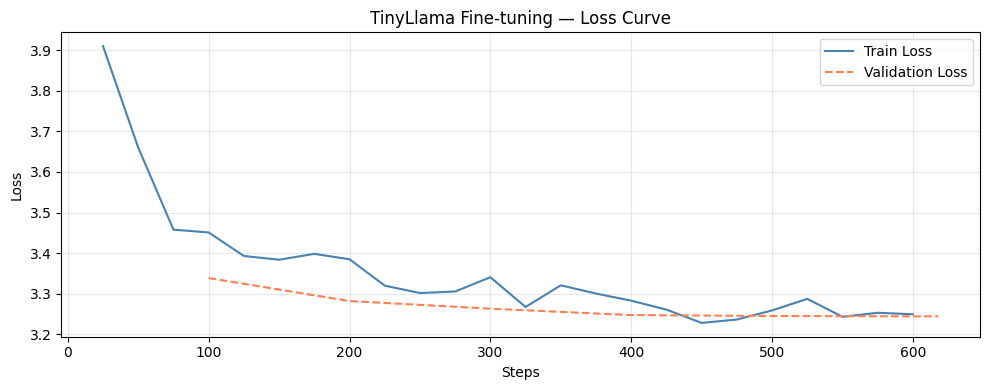

In [ ]:
import matplotlib.pyplot as plt

log_history  = trainer.state.log_history
train_steps  = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]
val_steps    = [x["step"] for x in log_history if "eval_loss" in x]
val_losses   = [x["eval_loss"] for x in log_history if "eval_loss" in x]

plt.figure(figsize=(10, 4))
plt.plot(train_steps,  train_losses, label="Train Loss",      color="steelblue")
plt.plot(val_steps,    val_losses,   label="Validation Loss", color="coral", linestyle="--")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("TinyLlama Fine-tuning — Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

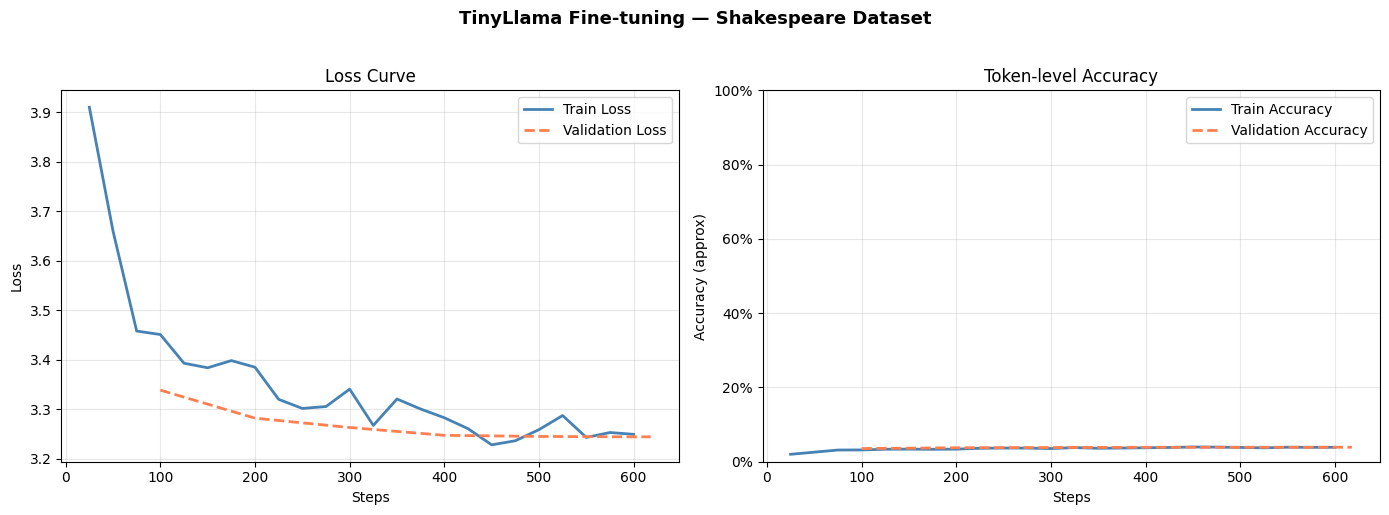

Plot saved to your Google Drive!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

log_history = trainer.state.log_history

train_steps  = [x["step"] for x in log_history if "loss" in x and "eval_loss" not in x]
train_losses = [x["loss"] for x in log_history if "loss" in x and "eval_loss" not in x]
val_steps    = [x["step"] for x in log_history if "eval_loss" in x]
val_losses   = [x["eval_loss"] for x in log_history if "eval_loss" in x]

# Token-level accuracy approximated from loss (acc = e^-loss capped at 1)
# Lower loss = higher accuracy
train_acc = [min(np.exp(-l), 1.0) for l in train_losses]
val_acc   = [min(np.exp(-l), 1.0) for l in val_losses]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss ---
axes[0].plot(train_steps, train_losses, label="Train Loss",      color="steelblue", linewidth=2)
axes[0].plot(val_steps,   val_losses,   label="Validation Loss", color="coral",     linewidth=2, linestyle="--")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Accuracy ---
axes[1].plot(train_steps, train_acc, label="Train Accuracy",      color="steelblue", linewidth=2)
axes[1].plot(val_steps,   val_acc,   label="Validation Accuracy", color="coral",     linewidth=2, linestyle="--")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Accuracy (approx)")
axes[1].set_title("Token-level Accuracy")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("TinyLlama Fine-tuning — Shakespeare Dataset", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Demo/CS4182_NLP/training_plots.png", bbox_inches="tight", dpi=150)
plt.show()
print("Plot saved to your Google Drive!")

Evaluate

In [ ]:
import math

eval_results = trainer.evaluate()
perplexity   = math.exp(eval_results["eval_loss"])

print(f"Validation Loss : {eval_results['eval_loss']:.4f}")
print(f"Perplexity      : {perplexity:.2f}")

if perplexity < 20:
    print("Excellent — model fits Shakespeare style very well.")
elif perplexity < 50:
    print("Good — model has learned the style reasonably well.")
else:
    print("Consider training more epochs or lowering learning rate.")

Training Loss,Validation Loss,Step,Entropy,Num Tokens,Mean Token Accuracy
3.249048,3.243796,618,3.249490,894987.000000,0.367440


Validation Loss : 3.2438
Perplexity      : 25.63
Good — model has learned the style reasonably well.


Demonstration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

def generate_text(model, tokenizer, prompt, max_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            max_length=None,
            do_sample=True,
            temperature=0.8,
            top_p=0.9,
            repetition_penalty=1.2,        # increased to reduce repetition
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    # Return only the newly generated text, not the prompt itself
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True)

# More varied prompts
prompts = [
    "To be or not to be,",
    "ROMEO: What light through yonder window breaks,",
    "All the world's a stage,",
    "HAMLET: To die, to sleep,",
    "MACBETH: Is this a dagger which I see before me,",
    "JULIET: O Romeo, Romeo, wherefore art thou Romeo,",
]

print("       TINYLLAMA — SHAKESPEARE STYLE GENERATION")


for i, prompt in enumerate(prompts, 1):
    print(f"[{i}/{len(prompts)}] PROMPT:")
    print(f"  ❝ {prompt} ❞")
    print("  CONTINUATION:")
    output = generate_text(model, tokenizer, prompt)
    # Pretty print with word wrap at 80 chars
    words = output.split()
    line = "  "
    for word in words:
        if len(line) + len(word) + 1 > 80:
            print(line)
            line = "  " + word + " "
        else:
            line += word + " "
    if line.strip():
        print(line)
    print("-" * 60 + "\n")

print("Generation complete!")

       TINYLLAMA — SHAKESPEARE STYLE GENERATION
[1/6] PROMPT:
  ❝ To be or not to be, ❞
  CONTINUATION:
  that's the question Which before the sun shines upon is light. First Citizen: 
  Is there no way? Second Citizen: I think not; but if a man be rich And know 
  what he has, why he should not use The means of it by using himself: for this 
  Warrant we have from his sovereign lord, 
------------------------------------------------------------

[2/6] PROMPT:
  ❝ ROMEO: What light through yonder window breaks, ❞
  CONTINUATION:
  That bright Morning sun! I do believe it was To drop upon us death. Nurse: O, 
  my son! This is a pestilent dream that cometh before me to waken thee from 
  thy sleep. My lord of Verona, is this the place Where thou hast set thine 
  eyes? CAPULET: No; not yet I am here 
------------------------------------------------------------

[3/6] PROMPT:
  ❝ All the world's a stage, ❞
  CONTINUATION:
  and all the sons of men Above a play. HORATIO: I am not so young

Compare base vs fine tuned model

In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

test_prompt = "KING: Hark, what news dost thou bring,"

print("BASE MODEL OUTPUT:")
print("-" * 40)
print(generate_text(base_model, tokenizer, test_prompt))

print("\nFINE-TUNED MODEL OUTPUT:")
print("-" * 40)
print(generate_text(model, tokenizer, test_prompt))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BASE MODEL OUTPUT:
----------------------------------------

O'er the seas and mountains?
KING OF THE WORLD TOGETHER!
They were waiting for you to arrive.
And here you stand, so tall,
A symbol of peace between nations,
Peace-bringing, that's your purpose,
Your heart is pure, oh how it shines,
Of love and freedom forevermore,
United in a worldly dream.

FINE-TUNED MODEL OUTPUT:
----------------------------------------
my lord? BRAKEFRIER: My lord! PALMER: How now, Brakefrier? how do you all?: well, good morn To you, bravery; and yet I'll find some news. First Citizen: Your grace hath no business here. Second Citizen: There is a mighty thing that comes upon
